# Sensitivity Analysis: Review + Pre-Application Levels

This notebook runs the permit simulation under:
- 3 duration levels (50%, 100%, 150%) for review stages
  - Planning
  - Public works
  - Fire
  - Special zoning
  - Agency referral
- 4 pre-application distribution options
  - baseline
  - lognormal_180
  - lognormal_60
  - poisson_10

It evaluates every selected combination and summarizes outcomes (e.g., mean total days, waiting/service, county vs applicant days).

In [1]:
import itertools
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_simulation
from visualize_permits import calculate_step_waiting_service_totals

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def run_duration_level_sensitivity(
    n_runs: int,
    num_permits: int,
    levels: list[float],
    pre_app_distributions: list[str],
    inter_arrival_time: float = 0.0,
    sequential: str = "standard",
    base_seed: int = 42,
):
    rows = []

    stages = [
        "planning",
        "public_works",
        "fire",
        "special_zoning",
        "agency_referral",
    ]
    step_names = [
        "EPA Debris",
        "USACE Debris",
        "Pre-Application Activities",
        "Applicant Revisions",
        "Planning",
        "Agency Referral",
        "Special Zoning",
        "Public Works",
        "Fire Review",
    ]
    level_combos = list(itertools.product(levels, repeat=len(stages)))

    for pre_app_dist in pre_app_distributions:
        for combo_vals in level_combos:
            multiplier_map = dict(zip(stages, combo_vals))
            combo_name = (
                f"pre_app={pre_app_dist} | "
                + " | ".join(f"{k}={v:.1f}x" for k, v in multiplier_map.items())
            )

            for run_idx in range(n_runs):
                seed = base_seed + run_idx
                sim = run_simulation(
                    num_permits=num_permits,
                    random_seed=seed,
                    inter_arrival_time=inter_arrival_time,
                    sequential=sequential,
                    review_duration_multipliers=multiplier_map,
                    pre_application_distribution=pre_app_dist,
                )
                stats = sim.get_statistics()
                if "message" in stats:
                    continue

                avg_total = stats.get("average_total_time") or {}
                total_wait = stats.get("total_waiting_time") or {}
                total_service = stats.get("total_service_time") or {}
                county_vs_app = stats.get("county_review_vs_applicant") or {}

                # Mean waiting/service time per permit for each step
                permits = sim.completed_permits
                n_permits = len(permits)

                # Planning-to-ready metric: from planning start to ready for construction
                planning_to_ready_days = [
                    (p.ready_for_construction - p.planning_request)
                    for p in permits
                    if p.planning_request is not None and p.ready_for_construction is not None
                ]
                mean_planning_to_ready_days = (
                    float(np.mean(planning_to_ready_days))
                    if planning_to_ready_days
                    else np.nan
                )

                # Debris gating metric: if debris ends after ready_for_construction,
                # permit would wait this additional time before construction can truly start.
                debris_blocking_wait_days = [
                    (p.debris_removal_end - p.ready_for_construction)
                    for p in permits
                    if p.debris_removal_end is not None
                    and p.ready_for_construction is not None
                    and p.debris_removal_end > p.ready_for_construction
                ]
                debris_blocking_wait_count = len(debris_blocking_wait_days)
                debris_blocking_wait_mean = (
                    float(np.mean(debris_blocking_wait_days))
                    if debris_blocking_wait_days
                    else 0.0
                )
                debris_blocking_wait_median = (
                    float(np.median(debris_blocking_wait_days))
                    if debris_blocking_wait_days
                    else 0.0
                )
                debris_blocking_wait_max = (
                    float(np.max(debris_blocking_wait_days))
                    if debris_blocking_wait_days
                    else 0.0
                )

                wait_sums = {s: 0.0 for s in step_names}
                service_sums = {s: 0.0 for s in step_names}
                for p in permits:
                    step_data = calculate_step_waiting_service_totals(p)
                    for s in step_names:
                        vals = step_data.get(s, {"waiting": 0.0, "service": 0.0})
                        wait_sums[s] += vals.get("waiting", 0.0)
                        service_sums[s] += vals.get("service", 0.0)

                step_cols = {}
                for s in step_names:
                    col_key = s.lower().replace(" ", "_").replace("-", "_")
                    denom = n_permits if n_permits > 0 else 1
                    step_cols[f"step_wait_mean__{col_key}"] = wait_sums[s] / denom
                    step_cols[f"step_service_mean__{col_key}"] = service_sums[s] / denom

                rows.append(
                    {
                        "combo": combo_name,
                        "pre_application_distribution": pre_app_dist,
                        "planning_level": multiplier_map["planning"],
                        "public_works_level": multiplier_map["public_works"],
                        "fire_level": multiplier_map["fire"],
                        "special_zoning_level": multiplier_map["special_zoning"],
                        "agency_referral_level": multiplier_map["agency_referral"],
                        "run": run_idx,
                        "seed": seed,
                        "completed_permits": n_permits,
                        "mean_total_days": avg_total.get("mean", np.nan),
                        "mean_application_to_ready_days": mean_planning_to_ready_days,
                        "planning_to_ready_n": len(planning_to_ready_days),
                        "debris_blocking_wait_count": debris_blocking_wait_count,
                        "debris_blocking_wait_share": (
                            debris_blocking_wait_count / n_permits if n_permits > 0 else np.nan
                        ),
                        "debris_blocking_wait_mean_days": debris_blocking_wait_mean,
                        "debris_blocking_wait_median_days": debris_blocking_wait_median,
                        "debris_blocking_wait_max_days": debris_blocking_wait_max,
                        "median_total_days": avg_total.get("median", np.nan),
                        "std_total_days": avg_total.get("std", np.nan),
                        "min_total_days": avg_total.get("min", np.nan),
                        "max_total_days": avg_total.get("max", np.nan),
                        "mean_wait_days": total_wait.get("mean", np.nan),
                        "mean_service_days": total_service.get("mean", np.nan),
                        "county_review_mean": county_vs_app.get("county_review_mean", np.nan),
                        "applicant_mean": county_vs_app.get("applicant_mean", np.nan),
                        "debris_mean": county_vs_app.get("debris_mean", np.nan),
                        "stats_json": json.dumps(stats),
                        **step_cols,
                    }
                )

    return pd.DataFrame(rows)

In [3]:
# --- Experiment settings ---
levels = [0.5, 1.0, 1.5]  # 50%, 100%, 150%
pre_app_distributions = ["lognormal_180", "lognormal_60", "poisson_10"]
# Add "baseline" to the list above if you want to include the original model behavior.

N_RUNS = 10
N_PERMITS = 1200
INTER_ARRIVAL = 0.0
SEQUENTIAL_MODE = "standard"  # "standard", "parallel", or "sequential"

results_df = run_duration_level_sensitivity(
    n_runs=N_RUNS,
    num_permits=N_PERMITS,
    levels=levels,
    pre_app_distributions=pre_app_distributions,
    inter_arrival_time=INTER_ARRIVAL,
    sequential=SEQUENTIAL_MODE,
    base_seed=42,
)

print(f"Rows: {len(results_df)}")
print(f"Unique combinations: {results_df['combo'].nunique()}")
print(f"Expected combinations: {len(pre_app_distributions) * (len(levels) ** 5)}")
results_df.head()

Rows: 7290
Unique combinations: 729
Expected combinations: 729


,combo,pre_application_distribution,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,run,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,stats_json,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
0,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,0.5,0.5,0.5,0.5,0.5,0,42,1200,288.053823,77.058673,1200,0,0.0,0.0,0.0,0.0,267.692766,125.511777,72.091020,1508.172520,11.275694,296.296008,19.024914,273.762966,14.783822,"{""total_completed"": 1200, ""total_in_progress"":...",3.235752,1.016461,8.039942,2.491667,0.0,210.995150,0.0,62.767816,0.0,3.411048,0.0,3.653125,0.0,5.470534,0.0,4.114951,0.0,2.375256
1,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,0.5,0.5,0.5,0.5,0.5,1,43,1200,285.094589,77.158055,1200,0,0.0,0.0,0.0,0.0,258.391728,117.461118,63.522803,902.011889,11.445985,293.327675,18.956019,270.847162,14.970479,"{""total_completed"": 1200, ""total_in_progress"":...",3.214872,1.010328,8.231113,2.514167,0.0,207.936534,0.0,62.910627,0.0,3.376748,0.0,3.810379,0.0,5.350791,0.0,4.155134,0.0,2.262967
2,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,0.5,0.5,0.5,0.5,0.5,2,44,1200,284.026906,77.669380,1200,0,0.0,0.0,0.0,0.0,260.121494,121.255174,85.706290,965.546160,11.247745,291.767315,18.275215,270.015434,14.724411,"{""total_completed"": 1200, ""total_in_progress"":...",3.137635,1.000832,8.110111,2.475833,0.0,206.357525,0.0,63.657909,0.0,3.358022,0.0,3.402284,0.0,5.067277,0.0,4.095092,0.0,2.352540
3,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,0.5,0.5,0.5,0.5,0.5,3,45,1200,283.368384,78.714191,1200,0,0.0,0.0,0.0,0.0,254.844455,119.307855,74.927339,1040.173550,11.283462,291.803199,19.664456,268.624221,14.797985,"{""total_completed"": 1200, ""total_in_progress"":...",3.147904,1.007022,8.135558,2.507500,0.0,204.654194,0.0,63.970027,0.0,3.401088,0.0,3.848679,0.0,5.836136,0.0,4.185679,0.0,2.392872
4,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,0.5,0.5,0.5,0.5,0.5,4,46,1200,282.778758,76.438629,1200,0,0.0,0.0,0.0,0.0,257.138034,124.755501,72.550399,1718.389678,11.265441,291.220029,19.121977,268.593931,14.769561,"{""total_completed"": 1200, ""total_in_progress"":...",3.226570,1.017454,8.038871,2.486667,0.0,206.340129,0.0,62.253802,0.0,3.384215,0.0,3.749470,0.0,5.333633,0.0,4.171243,0.0,2.483416


In [4]:
summary = (
    results_df
    .groupby([
        "pre_application_distribution",
        "planning_level",
        "public_works_level",
        "fire_level",
        "special_zoning_level",
        "agency_referral_level",
    ], as_index=False)
    .mean(numeric_only=True)
    .sort_values("mean_total_days")
    .reset_index(drop=True)
)

summary = summary.rename(columns={"run": "n_runs_proxy"})

print("Top 10 fastest combinations (by mean total days):")
display(summary.head(10))

print("Top 10 slowest combinations:")
display(summary.tail(10).sort_values("mean_total_days", ascending=False))

Top 10 fastest combinations (by mean total days):


,pre_application_distribution,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,n_runs_proxy,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
0,poisson_10,0.5,0.5,0.5,0.5,0.5,4.5,46.5,1200.0,93.366197,83.364781,1200.0,20.3,0.016917,7.340947,5.433589,24.284132,89.550649,30.136042,18.142003,271.938455,16.693427,96.395186,24.683315,73.535525,14.869772,3.190265,1.008093,8.174414,2.497000,0.0,10.001417,0.0,63.534108,5.328748,3.395805,0.0,3.876987,0.0,5.566084,0.0,4.167194,0.000000,2.348497
1,poisson_10,0.5,0.5,1.0,0.5,0.5,4.5,46.5,1200.0,95.237480,85.236064,1200.0,17.3,0.014417,7.362051,5.768609,21.837250,91.249837,30.323513,20.763729,275.149058,16.714708,98.772099,27.084474,73.529331,14.873001,3.171074,1.001971,8.199540,2.500417,0.0,10.001417,0.0,63.527915,5.314520,3.398155,0.0,3.790433,0.0,5.673113,0.0,4.161768,0.029574,4.716911
2,poisson_10,0.5,0.5,0.5,0.5,1.0,4.5,46.5,1200.0,95.599279,85.597862,1200.0,20.2,0.016833,7.390060,5.470343,24.284132,90.176380,33.853083,18.142003,329.469414,16.693427,100.272173,28.560303,73.535525,14.869772,3.190265,1.008093,8.174414,2.497000,0.0,10.001417,0.0,63.534108,5.328748,3.395805,0.0,7.753974,0.0,5.566084,0.0,4.167194,0.000000,2.348497
3,poisson_10,0.5,1.0,0.5,0.5,0.5,4.5,46.5,1200.0,97.023636,87.022220,1200.0,10.6,0.008833,7.678994,5.563949,23.188069,93.237691,30.506325,20.501103,293.004959,16.668853,100.310965,28.721325,73.407793,14.850701,3.180024,1.007083,8.167427,2.496167,0.0,10.001417,0.0,63.406376,5.321402,3.402553,0.0,3.685361,0.0,5.660222,0.0,8.330616,0.000000,2.321171
4,poisson_10,0.5,0.5,1.5,0.5,0.5,4.5,46.5,1200.0,97.181430,87.180013,1200.0,14.0,0.011667,8.534781,7.360703,22.546183,93.276174,31.112366,18.656409,312.799412,20.748874,101.519029,33.591488,73.829929,14.846487,3.162733,1.002606,8.186482,2.494667,0.0,10.001417,0.0,63.828512,5.334449,3.404819,0.0,3.764413,0.0,5.863276,0.0,4.162571,4.065211,6.996749
5,poisson_10,0.5,0.5,1.0,0.5,1.0,4.5,46.5,1200.0,97.262633,87.261216,1200.0,17.3,0.014417,7.362051,5.768609,21.837250,91.823424,33.580555,20.763729,321.062771,16.714708,102.562532,30.874907,73.529331,14.873001,3.171074,1.001971,8.199540,2.500417,0.0,10.001417,0.0,63.527915,5.314520,3.398155,0.0,7.580866,0.0,5.673113,0.0,4.161768,0.029574,4.716911
6,poisson_10,0.5,1.0,1.0,0.5,0.5,4.5,46.5,1200.0,97.966878,87.965461,1200.0,12.1,0.010083,6.193021,5.693632,16.010357,94.103842,30.180641,22.936099,264.634716,16.724531,102.631840,31.182490,73.300330,14.873551,3.182321,1.010112,8.183118,2.498000,0.0,10.001417,0.0,63.298913,5.326796,3.400222,0.0,3.771529,0.0,5.604145,0.0,8.330864,0.032296,4.716639
7,poisson_10,0.5,0.5,0.5,0.5,1.5,4.5,46.5,1200.0,98.638843,88.637427,1200.0,20.2,0.016833,7.390060,5.470343,24.284132,90.863401,40.213431,18.142003,439.462158,16.693427,104.149160,32.437290,73.535525,14.869772,3.190265,1.008093,8.174414,2.497000,0.0,10.001417,0.0,63.534108,5.328748,3.395805,0.0,11.630962,0.0,5.566084,0.0,4.167194,0.000000,2.348497
8,poisson_10,0.5,1.0,0.5,0.5,1.0,4.5,46.5,1200.0,99.020706,89.019289,1200.0,10.5,0.008750,7.592885,5.353122,23.

Top 10 slowest combinations:


,pre_application_distribution,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,n_runs_proxy,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
728,lognormal_180,1.5,1.5,1.5,1.5,1.5,4.5,46.5,1200.0,319.001552,110.803804,1200.0,0.0,0.0,0.0,0.0,0.0,290.019604,136.705545,96.869704,1339.556405,11.333150,333.254647,58.200305,271.552335,14.835157,3.168906,1.004757,8.164244,2.497250,0.0,208.197748,0.0,63.354587,0.0,10.208352,0.0,11.331708,0.0,17.242098,0.0,12.456859,0.0,6.961288
727,lognormal_180,1.5,1.5,1.0,1.5,1.5,4.5,46.5,1200.0,317.785291,109.587543,1200.0,0.0,0.0,0.0,0.0,0.0,289.945553,136.397467,94.689570,1316.595158,11.333150,330.845617,55.770864,271.572745,14.835157,3.168906,1.004757,8.164244,2.497250,0.0,208.197748,0.0,63.374998,0.0,10.210379,0.0,11.215976,0.0,17.162453,0.0,12.483108,0.0,4.698949
726,lognormal_180,1.5,1.5,0.5,1.5,1.5,4.5,46.5,1200.0,317.339966,109.142219,1200.0,0.0,0.0,0.0,0.0,0.0,288.203970,137.261348,91.935117,1291.058490,11.333160,328.726133,53.698316,271.525810,14.835167,3.168906,1.004757,8.164254,2.497250,0.0,208.197748,0.0,63.328062,0.0,10.203421,0.0,11.368905,0.0,17.277146,0.0,12.515550,0.0,2.333294
725,lognormal_180,1.5,1.0,1.5,1.5,1.5,4.5,46.5,1200.0,316.558025,108.360277,1200.0,0.0,0.0,0.0,0.0,0.0,287.564736,136.930732,89.169996,1309.237156,11.333150,329.962940,54.833354,271.627663,14.835074,3.168906,1.004757,8.164244,2.497167,0.0,208.197748,0.0,63.429915,0.0,10.210043,0.0,11.410738,0.0,17.835508,0.0,8.301893,0.0,7.075171
724,lognormal_180,1.5,1.5,1.5,1.5,1.0,4.5,46.5,1200.0,316.136717,107.938969,1200.0,0.0,0.0,0.0,0.0,0.0,288.237019,133.962095,96.869704,1328.887147,11.333150,329.477411,54.423069,271.552335,14.835157,3.168906,1.004757,8.164244,2.497250,0.0,208.197748,0.0,63.354587,0.0,10.208352,0.0,7.554472,0.0,17.242098,0.0,12.456859,0.0,6.961288
723,lognormal_180,1.0,1.5,1.5,1.5,1.5,4.5,46.5,1200.0,316.032219,107.834472,1200.0,0.0,0.0,0.0,0.0,0.0,286.692874,135.676346,86.792800,1300.369567,11.334772,330.402848,55.075827,271.825206,14.836587,3.169246,1.004649,8.165525,2.497167,0.0,208.197748,0.0,63.627458,0.0,6.815680,0.0,11.537303,0.0,17.241620,0.0,12.476455,0.0,7.004770
722,lognormal_180,1.5,1.5,1.0,1.5,1.0,4.5,46.5,1200.0,314.916759,106.719011,1200.0,0.0,0.0,0.0,0.0,0.0,287.271268,133.713797,94.689570,1292.527550,11.333150,327.106958,52.032206,271.572745,14.835157,3.168906,1.004757,8.164244,2.497250,0.0,208.197748,0.0,63.374998,0.0,10.210379,0.0,7.477318,0.0,17.162453,0.0,12.483108,0.0,4.698949
721,lognormal_180,1.0,1.5,1.0,1.5,1.5,4.5,46.5,1200.0,314.767351,106.569604,1200.0,0.0,0.0,0.0,0.0,0.0,284.969830,136.339312,87.759221,1370.133908,11.334866,327.901746,52.607902,271.791945,14.836765,3.169246,1.004649,8.165619,2.497250,0.0,208.197748,0.0,63.594197,0.0,6.810828,0.0,11.554571,0.0,17.118101,0.0,12.457339,0.0,4.667062
720,lognormal_180,1.5,1.0,1.0,1.5,1.5,4.5,46.5,1200.0,314.677206,106.479459,1200.0,0.0,0.0,0.0,0.0,0.0,285.314461,136.790855,91.047411,1351.623737,11.333150,327.219512,52.176542,271.541130,14.834991,3.168906,1.004757,8.164244,2.497083,0.0,208.

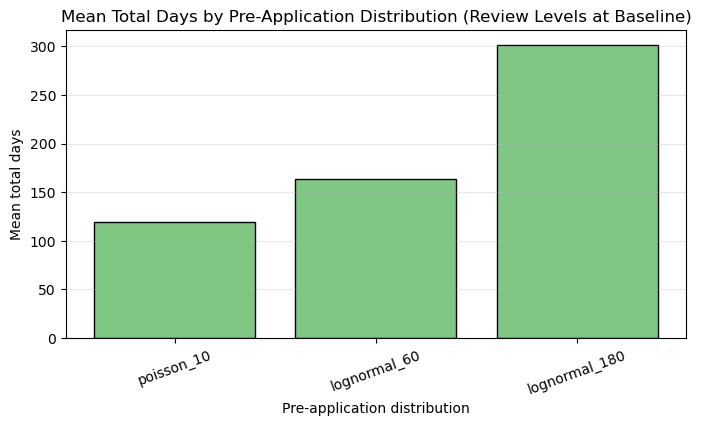

In [5]:
# Optional visualization: compare pre-application distributions at baseline review levels
plot_df = summary[
    (summary["planning_level"] == 1.0)
    & (summary["public_works_level"] == 1.0)
    & (summary["fire_level"] == 1.0)
    & (summary["special_zoning_level"] == 1.0)
    & (summary["agency_referral_level"] == 1.0)
].copy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    plot_df["pre_application_distribution"],
    plot_df["mean_total_days"],
    color="#81C784",
    edgecolor="black",
)
ax.set_title("Mean Total Days by Pre-Application Distribution (Review Levels at Baseline)")
ax.set_xlabel("Pre-application distribution")
ax.set_ylabel("Mean total days")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.show()

In [6]:
# Export CSV outputs (every run + grouped summary)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
runs_csv = f"sensitivity_runs_all_combinations_{timestamp}.csv"
summary_csv = f"sensitivity_summary_all_combinations_{timestamp}.csv"

results_df.to_csv(runs_csv, index=False)
summary.to_csv(summary_csv, index=False)

print(f"Saved per-run results: {runs_csv}")
print(f"Saved grouped summary: {summary_csv}")
print(f"Per-run rows exported: {len(results_df)}")
print(f"Unique parameter combinations: {summary.shape[0]}")

summary.head()

Saved per-run results: sensitivity_runs_all_combinations_20260414_111224.csv
Saved grouped summary: sensitivity_summary_all_combinations_20260414_111224.csv
Per-run rows exported: 7290
Unique parameter combinations: 729


,pre_application_distribution,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,n_runs_proxy,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
0,poisson_10,0.5,0.5,0.5,0.5,0.5,4.5,46.5,1200.0,93.366197,83.364781,1200.0,20.3,0.016917,7.340947,5.433589,24.284132,89.550649,30.136042,18.142003,271.938455,16.693427,96.395186,24.683315,73.535525,14.869772,3.190265,1.008093,8.174414,2.497000,0.0,10.001417,0.0,63.534108,5.328748,3.395805,0.0,3.876987,0.0,5.566084,0.0,4.167194,0.000000,2.348497
1,poisson_10,0.5,0.5,1.0,0.5,0.5,4.5,46.5,1200.0,95.237480,85.236064,1200.0,17.3,0.014417,7.362051,5.768609,21.837250,91.249837,30.323513,20.763729,275.149058,16.714708,98.772099,27.084474,73.529331,14.873001,3.171074,1.001971,8.199540,2.500417,0.0,10.001417,0.0,63.527915,5.314520,3.398155,0.0,3.790433,0.0,5.673113,0.0,4.161768,0.029574,4.716911
2,poisson_10,0.5,0.5,0.5,0.5,1.0,4.5,46.5,1200.0,95.599279,85.597862,1200.0,20.2,0.016833,7.390060,5.470343,24.284132,90.176380,33.853083,18.142003,329.469414,16.693427,100.272173,28.560303,73.535525,14.869772,3.190265,1.008093,8.174414,2.497000,0.0,10.001417,0.0,63.534108,5.328748,3.395805,0.0,7.753974,0.0,5.566084,0.0,4.167194,0.000000,2.348497
3,poisson_10,0.5,1.0,0.5,0.5,0.5,4.5,46.5,1200.0,97.023636,87.022220,1200.0,10.6,0.008833,7.678994,5.563949,23.188069,93.237691,30.506325,20.501103,293.004959,16.668853,100.310965,28.721325,73.407793,14.850701,3.180024,1.007083,8.167427,2.496167,0.0,10.001417,0.0,63.406376,5.321402,3.402553,0.0,3.685361,0.0,5.660222,0.0,8.330616,0.000000,2.321171
4,poisson_10,0.5,0.5,1.5,0.5,0.5,4.5,46.5,1200.0,97.181430,87.180013,1200.0,14.0,0.011667,8.534781,7.360703,22.546183,93.276174,31.112366,18.656409,312.799412,20.748874,101.519029,33.591488,73.829929,14.846487,3.162733,1.002606,8.186482,2.494667,0.0,10.001417,0.0,63.828512,5.334449,3.404819,0.0,3.764413,0.0,5.863276,0.0,4.162571,4.065211,6.996749
